# 1- Import data from a website using the requests library and format it as a reusable DataFrame.

In [118]:
import requests
import pandas as pd 
def extract_all_data():
    x=["1000","2000","3000","4000","5500"]
    data= ""
    for x_i in x:
        data += requests.get(f'https://cogcomp.seas.upenn.edu/Data/QA/QC/train_{x_i}.label').text
        data += "\n"
    data_list=data.split("\n")
    data_json = {
        "target" : [],
        "question" : [] 
    }
    for d in data_list :
        try:
          if(len(d) > 0) :
            index = d.index(':') #The index() method in Python is used to find the first occurrence of a specified value within a string
            label, question = d[:index],d[index+1:]
            data_json["target"].append(label)
            data_json["question"].append(question)
        except:
            print(d)
    return data_json
        
        
train_data=pd.DataFrame(extract_all_data())


# Exploration 

In [119]:
train_data.head()


,target,question
0,DESC,manner How did serfdom develop in and then lea...
1,ENTY,cremat What films featured the character Popey...
2,DESC,manner How can I find a list of celebrities ' ...
3,ENTY,animal What fowl grabs the spotlight after the...
4,ABBR,exp What is the full form of .com ?


In [120]:
list( train_data["target"].unique() )
   

['DESC', 'ENTY', 'ABBR', 'HUM', 'NUM', 'LOC']

# 2 -Data Preprocessing

In [121]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from nltk.stem import WordNetLemmatizer
import re
import string 
import inflect
import contractions

p_inf = inflect.engine()
tokens = word_tokenize(" Hello word i am his bitch ") 
stop_words = set(stopwords.words('english'))
p = PorterStemmer()
def convert_number(text):
    tokens = word_tokenize(text)
    for i in range(len(tokens)):
        if(tokens[i].isdigit()):
            tokens[i] = p_inf.number_to_words(tokens[i])
    return " ".join(tokens)
def remove_punctuation(text):
    translator= str.maketrans('','',string.punctuation)
    return text.translate(translator)
# methode to clean text 

def preprocess_text (text):
    
    """
    Clean, tokenize, and stem the input text.

    Steps:
    - Convert to lowercase
    - Remove extra whitespace
    - Convert numbers to words
    - Remove punctuation
    - Remove stopwords
    - Apply stemming
    """
    #Text Lowercase
    text = text.lower()
    ##don't to do not 
    text = contractions.fix(text)
    ## special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # remove whitespace from text
    text = " ".join(text.split())
    # convert numbers to text
    text = convert_number(text)
    # remove punctuation
    text = remove_punctuation(text)
    # Apply stemming
    text= " ".join( [w for w in word_tokenize(text) if w not in stop_words ])
    return  " ".join([ p.stem(w) for w in word_tokenize(text) ] ) 

input_text = "Hello world! I am excited to learn text preprocessing."
cleaned_text = preprocess_text(input_text)
print(cleaned_text)



hello world excit learn text preprocess


In [122]:
nltk.download('punkt_tab')       # For word tokenization
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\omara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\omara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [123]:

questions = train_data.question.str.cat(sep = ' ')
tokens = word_tokenize(preprocess_text(questions))
tokens = [w for w in tokens ]
vocabulary = set(tokens)
frequency_dist = nltk.FreqDist(tokens)
#sorted(frequency_dist,key=frequency_dist.__getitem__, reverse=True)[0:50]

# 3 - Data Visulizations

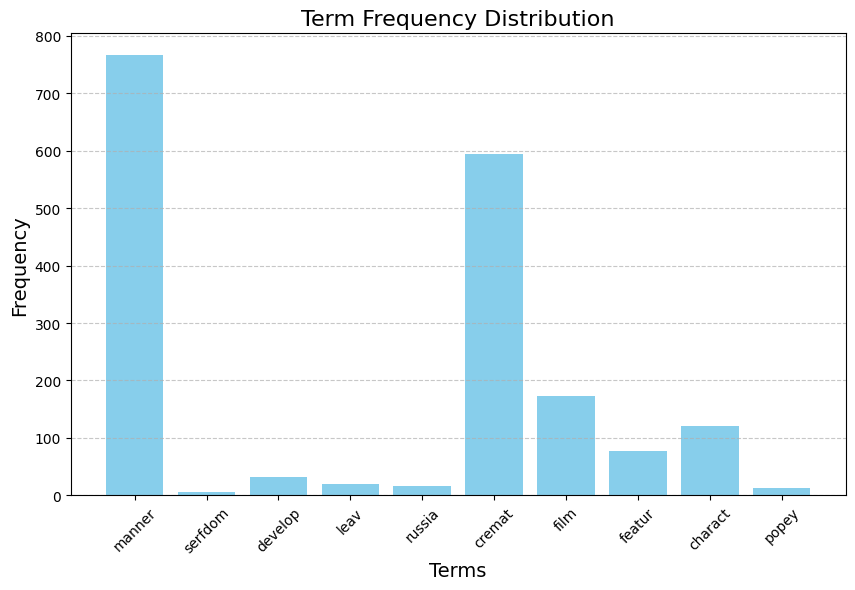

In [124]:
import matplotlib.pyplot as plt

terms = list(frequency_dist.keys())[0:10]
frequencies = list(frequency_dist.values())[0:10]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(terms, frequencies, color='skyblue')
plt.xlabel("Terms", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Term Frequency Distribution", fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

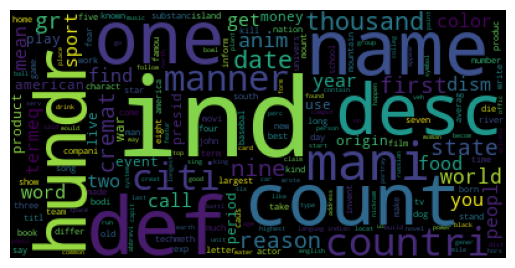

In [125]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wordcloud = WordCloud().generate_from_frequencies(frequency_dist)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# 4 - Transform Data into usefull Representation


In [126]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing 
label_encoder = preprocessing.LabelEncoder() 
X,y = train_data.question,label_encoder.fit_transform(train_data.target)
(X_train, X_test, y_train, y_test) = train_test_split(X, y,test_size = .2,random_state = 22)


In [127]:
def get_corpus(X):
     corpus = list(X)
     vocabulary = set(corpus)

     new_corpus = []
     for c in corpus :
        new_corpus.append(preprocess_text(c))
     return new_corpus
corpus_train=get_corpus(X_train)
corpus_test = get_corpus(X_test)


In [128]:
#from sklearn.feature_extraction.text import TfidfTransformer
#from sklearn.feature_extraction.text import TfidfVectorizer
model = SentenceTransformer("all-MiniLM-L6-v2")


train_model_data = model.encode(corpus_train)
test_model_data = model.encode(corpus_test)
print(train_model_data.shape, test_model_data.shape)

(12361, 384) (3091, 384)


In [129]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [130]:
train_model_data = torch.tensor(train_model_data,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.long)

test_model_data = torch.tensor(test_model_data,dtype=torch.float32)


In [131]:
import torch
import torch.nn as nn

class QuestionClassificationModelGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0):
        super(QuestionClassificationModelGRU, self).__init__()
        
        # GRU Layer
        self.gru = nn.GRU(
            input_size, 
            hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout, 
            bidirectional=True  # Bidirectional GRU
        )
        
        # Fully Connected Layer
        self.fc = nn.Linear(hidden_size * 2, output_size)  # *2 for bidirectional GRU

    def forward(self, x):
        # GRU Forward Pass
        gru_out, _ = self.gru(x)
        
        # Use the last hidden state for classification
        out = self.fc(gru_out[:, -1, :])  # Last hidden state
        
        return out

# Hyperparameters
input_size = 384  # Size of the embeddings from SentenceTransformer
hidden_size = 128  # Number of features in hidden state
output_size = len(label_encoder.classes_)  # Number of classes
num_layers = 3
dropout = 0  # Dropout for regularization
learning_rate = 0.001
num_epochs = 50

# Initialize model, loss, and optimizer
model_gru = QuestionClassificationModelGRU(input_size, hidden_size, output_size, num_layers, dropout)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=learning_rate)

# Convert data to appropriate shape
train_model_data = torch.tensor(train_model_data, dtype=torch.float32).unsqueeze(1)  # Add sequence length dimension (batch, seq_len, input_size)
test_model_data = torch.tensor(test_model_data, dtype=torch.float32).unsqueeze(1)   # Add sequence length dimension

# Train the GRU model
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_gru(train_model_data)
    loss = criterion(outputs, y_train.long())  # Ensure y_train is of type Long
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred = model_gru(test_model_data)
    y_pred_classes = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_classes == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")


C:\Users\omara\AppData\Local\Temp\ipykernel_24320\2187452923.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_model_data = torch.tensor(train_model_data, dtype=torch.float32).unsqueeze(1)  # Add sequence length dimension (batch, seq_len, input_size)
C:\Users\omara\AppData\Local\Temp\ipykernel_24320\2187452923.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_model_data = torch.tensor(test_model_data, dtype=torch.float32).unsqueeze(1)   # Add sequence length dimension


Epoch [1/50], Loss: 1.7922
Epoch [2/50], Loss: 1.7799
Epoch [3/50], Loss: 1.7679
Epoch [4/50], Loss: 1.7558
Epoch [5/50], Loss: 1.7430
Epoch [6/50], Loss: 1.7294
Epoch [7/50], Loss: 1.7149
Epoch [8/50], Loss: 1.6996
Epoch [9/50], Loss: 1.6837
Epoch [10/50], Loss: 1.6678
Epoch [11/50], Loss: 1.6526
Epoch [12/50], Loss: 1.6387
Epoch [13/50], Loss: 1.6262
Epoch [14/50], Loss: 1.6142
Epoch [15/50], Loss: 1.6016
Epoch [16/50], Loss: 1.5877
Epoch [17/50], Loss: 1.5726
Epoch [18/50], Loss: 1.5566
Epoch [19/50], Loss: 1.5397
Epoch [20/50], Loss: 1.5208
Epoch [21/50], Loss: 1.4986
Epoch [22/50], Loss: 1.4720
Epoch [23/50], Loss: 1.4406
Epoch [24/50], Loss: 1.4043
Epoch [25/50], Loss: 1.3636
Epoch [26/50], Loss: 1.3186
Epoch [27/50], Loss: 1.2698
Epoch [28/50], Loss: 1.2180
Epoch [29/50], Loss: 1.1641
Epoch [30/50], Loss: 1.1095
Epoch [31/50], Loss: 1.0557
Epoch [32/50], Loss: 1.0042
Epoch [33/50], Loss: 0.9557
Epoch [34/50], Loss: 0.9102
Epoch [35/50], Loss: 0.8674
Epoch [36/50], Loss: 0.8277
E

In [137]:
import torch
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder

# Assuming you already have your trained GRU model and label encoder
model_gru.eval()  # Set model to evaluation mode

# Function to preprocess the input question
def preprocess_question(question):
    # Assuming you have the preprocess_text function defined as you provided earlier
    return preprocess_text(question)

# Function to convert question to embedding using SentenceTransformer
def get_embedding(question, model):
    # Preprocess the input question
    preprocessed_question = preprocess_question(question)
    
    # Get the embedding from SentenceTransformer (returns a numpy array)
    embedding = model.encode([preprocessed_question])  # Process as a batch of 1 item
    embedding_tensor = torch.tensor(embedding, dtype=torch.float32)  # Convert to tensor
    return embedding_tensor.unsqueeze(0)  # Add batch dimension

# Test question
test_question = "where is spain ?"

# Get the embedding for the test question
embedding = get_embedding(test_question, SentenceTransformer("all-MiniLM-L6-v2"))

# Predict using the GRU model
with torch.no_grad():
    output = model_gru(embedding)  # Feed embedding through the GRU model
    predicted_class = torch.argmax(output, dim=1)  # Get the predicted class index

# Decode the predicted class to label
predicted_label = label_encoder.inverse_transform(predicted_class.numpy())

print(f"Predicted class: {predicted_label[0]}")


Predicted class: LOC
